In [2]:
import numpy as np
import matplotlib.pyplot as plt

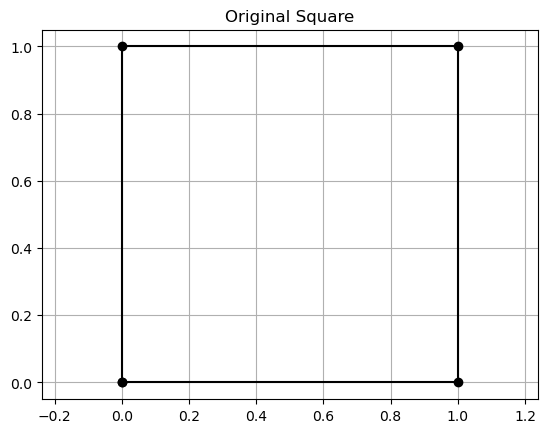

In [3]:
# Define a square (4 points, closed shape)
square = np.array([[0, 1, 1, 0, 0],
                   [0, 0, 1, 1, 0]])
plt.plot(square[0], square[1], 'k-o')
plt.title('Original Square')
plt.axis('equal')
plt.grid(True)
plt.show()

## The above code plots the square in the following way:


square[0]: x-values → $[0, 1, 1, 0, 0]$

square[1]: y-values → $[0, 0, 1, 1, 0]$

These points represent:


| Index   |   (x,y) point  |
|---------|----------------|
|  0      |    (0,0)       |
|  1      |    (1,0)       |
|  2      |    (1,1)       |
|  3      |    (0,1)       |
|  4      |    (0,0)       |← repeat of starting point to close the square


So the points go:
(0,0) → (1,0) → (1,1) → (0,1) → (0,0)
which traces a square in a counter-clockwise direction.


The 'k-o' argument in plt.plot(square[0], square[1], 'k-o'):

'k' → black color

'-' → solid lines between points

'o' → dots at each point

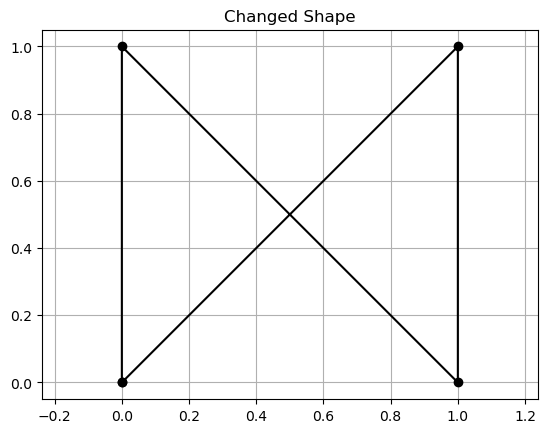

In [4]:
# Changed order of vertices

changed_shape = np.array([[0, 1, 1, 0, 0],
                   [0, 1, 0, 1, 0]])
plt.plot(changed_shape[0], changed_shape[1], 'k-o')
plt.title('Changed Shape')
plt.axis('equal')
plt.grid(True)
plt.show()

In [5]:
# Defining matrices of standard linear transformations

# Parameters for scaling
scale_factor1 = 2 
scale_factor2 = 3

# Parameter for rotation
angle_degrees = 45
angle_radians = (np.pi/180)*angle_degrees

# Parameter for reflection
line_angle_degrees = 30
line_angle_radians = (np.pi/180)*line_angle_degrees

# Parameter for shear (horizontal)
k = 1

# Parameter for shear (vertical)
k = 2


matrices = {
    "Identity": np.array([[1, 0], 
                          [0, 1]]),
    "Scaling": np.array([[scale_factor1, 0], 
                         [0, scale_factor2]]),
    "Rotation": np.array([[np.cos(angle_radians), -np.sin(angle_radians)], 
                          [np.sin(angle_radians), np.cos(angle_radians)]]),
    "Reflection (About ray with angle theta)": np.array([[np.cos(2*line_angle_radians), np.sin(2*line_angle_radians)], 
                                     [np.sin(2*line_angle_radians), -np.cos(2*line_angle_radians)]]),
    "Shear (Horizontal)": np.array([[1, k], 
                                    [0, 1]]),
    "Shear (Vertical)": np.array([[1, 0], 
                                  [k, 1]]),
    "Projection (onto x-axis)": np.array([[1, 0], [0, 0]]),
    "Projection (onto y-axis)": np.array([[0, 0], [0, 1]])
}
matrices

{'Identity': array([[1, 0],
        [0, 1]]),
 'Scaling': array([[2, 0],
        [0, 3]]),
 'Rotation': array([[ 0.70710678, -0.70710678],
        [ 0.70710678,  0.70710678]]),
 'Reflection (About ray with angle theta)': array([[ 0.5      ,  0.8660254],
        [ 0.8660254, -0.5      ]]),
 'Shear (Horizontal)': array([[1, 2],
        [0, 1]]),
 'Shear (Vertical)': array([[1, 0],
        [2, 1]]),
 'Projection (onto x-axis)': array([[1, 0],
        [0, 0]]),
 'Projection (onto y-axis)': array([[0, 0],
        [0, 1]])}

In [6]:
def plot_transformation(matrix, shape, title):
    transformed = matrix @ shape
    print(transformed)
    plt.plot(shape[0], shape[1], 'k--', label='Original')
    plt.plot(transformed[0], transformed[1], 'r-', label='Transformed')
    plt.title(title + f"\nDeterminant = {np.linalg.det(matrix):.2f}")
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.show()

[[0 1 1 0 0]
 [0 0 1 1 0]]


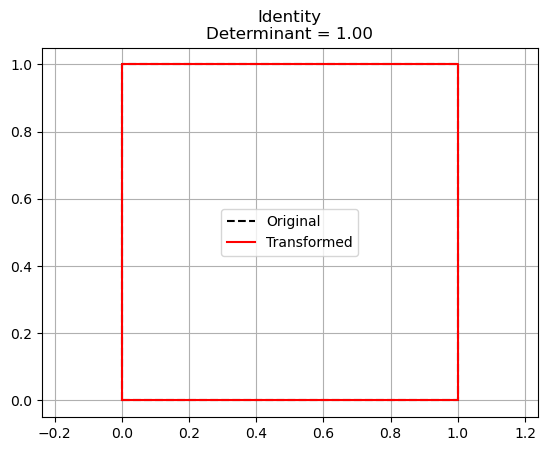

[[0 2 2 0 0]
 [0 0 3 3 0]]


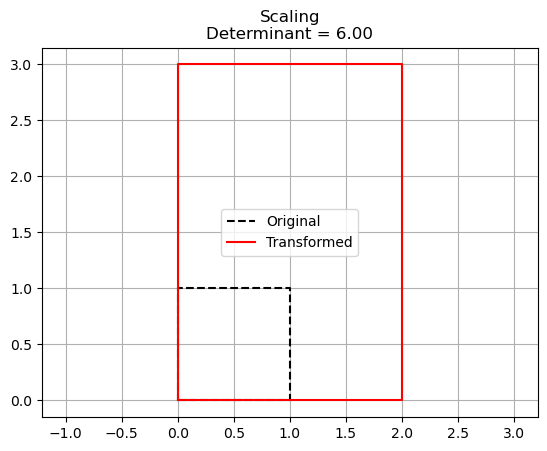

[[ 0.          0.70710678  0.         -0.70710678  0.        ]
 [ 0.          0.70710678  1.41421356  0.70710678  0.        ]]


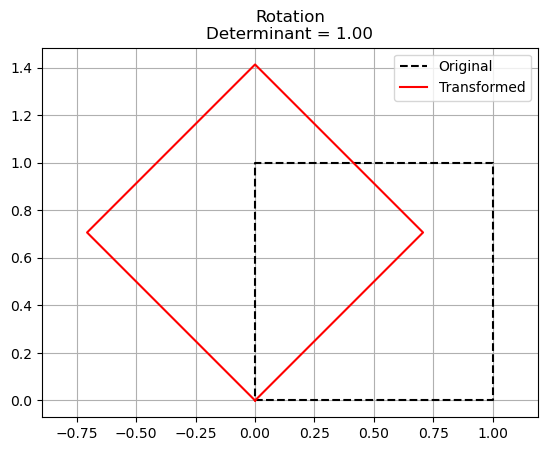

[[ 0.         0.5        1.3660254  0.8660254  0.       ]
 [ 0.         0.8660254  0.3660254 -0.5        0.       ]]


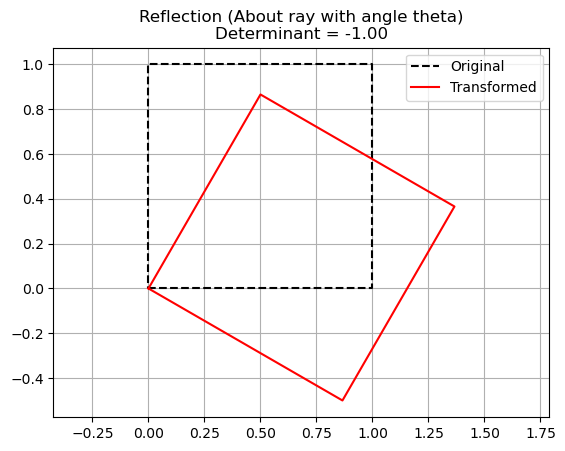

[[0 1 3 2 0]
 [0 0 1 1 0]]


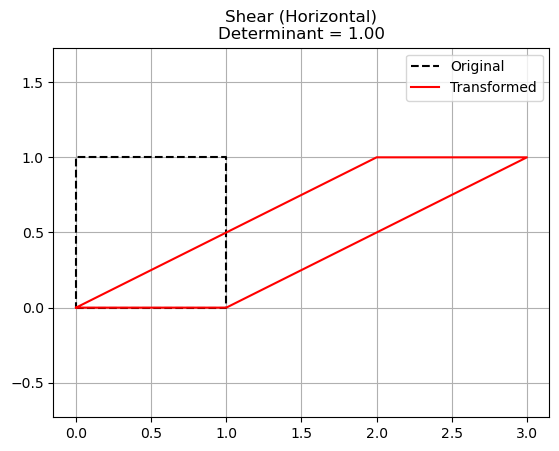

[[0 1 1 0 0]
 [0 2 3 1 0]]


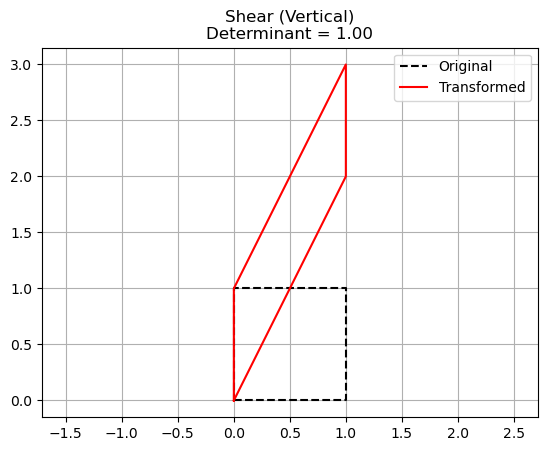

[[0 1 1 0 0]
 [0 0 0 0 0]]


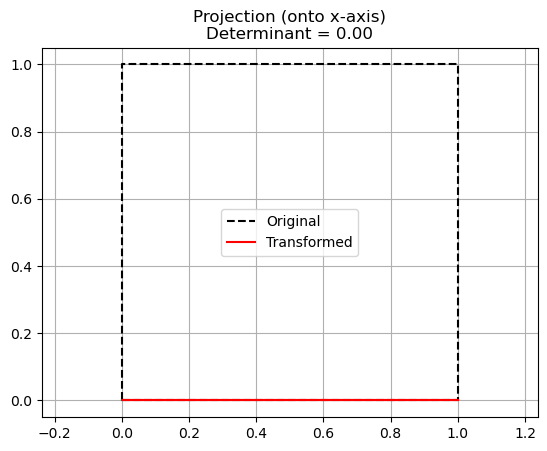

[[0 0 0 0 0]
 [0 0 1 1 0]]


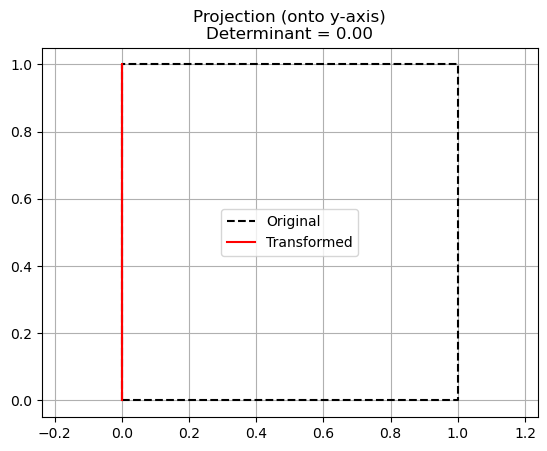

In [7]:
for name, M in matrices.items():
    plot_transformation(M, square, name)

## EXERCISES

1. Rotate the unit square by 90 degrees, 180 degrees, 270 degrees and 360 degrees counter-clockwise, and then clockwise.
2. Reflect the point (1,0) about the line y = x and the point (0,1) about the line y = -x using matrices.


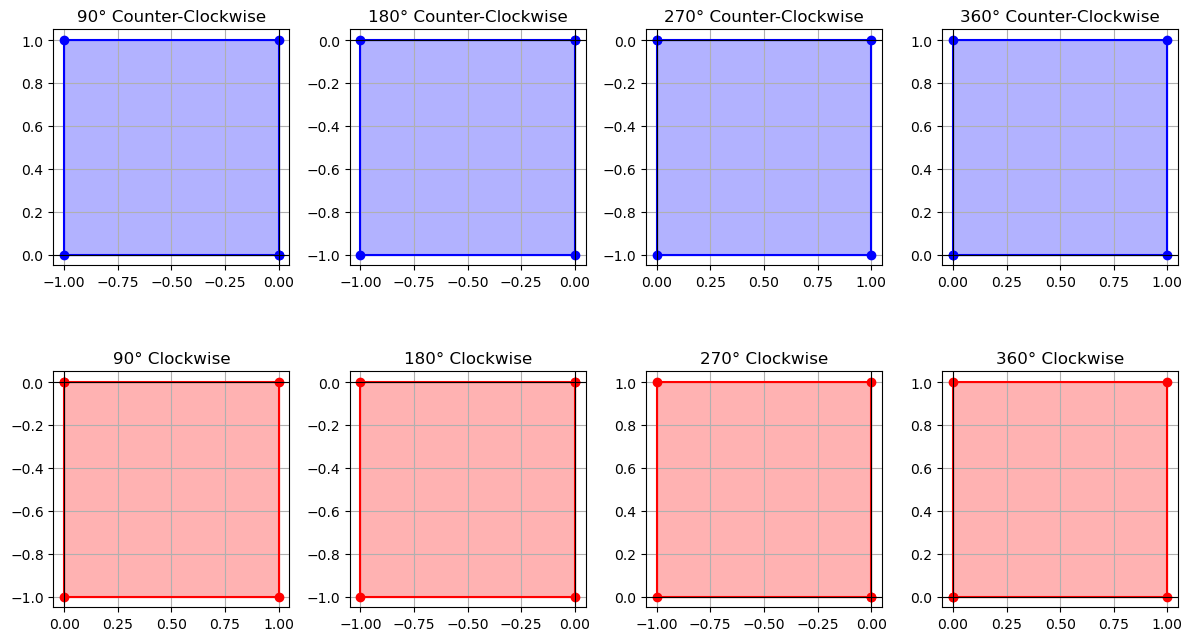

Reflection about y = x:
(1, 0) -> [0 1]

Reflection about y = -x:
(0, 1) -> [-1  0]


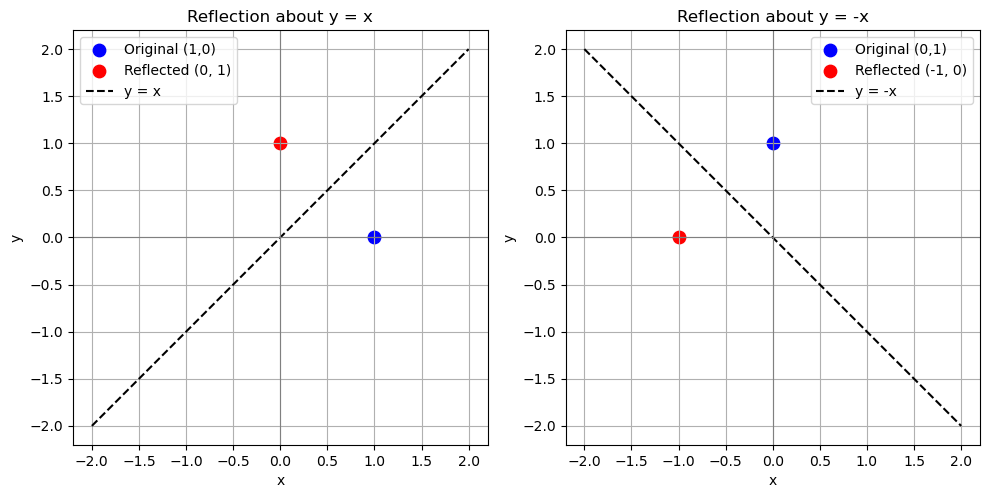

In [8]:
square = np.array([
    [0, 0],
    [1, 0],
    [1, 1],
    [0, 1]
])

def rotation_matrix(angle):
    """Return the 2D counter-clockwise rotation matrix."""
    theta = np.radians(angle)

    return np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])



ccw_angles = [90, 180, 270, 360]

cw_angles = [-90, -180, -270, -360]


fig, axes = plt.subplots(2, 4, figsize=(12, 7))


for ax, angle in zip(axes[0], ccw_angles):
    R = rotation_matrix(angle)
    rotated_square = square @ R.T

    ax.fill(rotated_square[:, 0], rotated_square[:, 1],
            alpha=0.3, color='blue')
    ax.plot(
        np.append(rotated_square[:, 0], rotated_square[0, 0]),
        np.append(rotated_square[:, 1], rotated_square[0, 1]),
        'b-o'
    )

    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)

    ax.set_title(f"{angle}° Counter-Clockwise")
    ax.set_aspect('equal')
    ax.grid(True)


for ax, angle in zip(axes[1], cw_angles):
    R = rotation_matrix(angle)

    rotated_square = square @ R.T

    ax.fill(rotated_square[:, 0], rotated_square[:, 1],
            alpha=0.3, color='red')
    ax.plot(
        np.append(rotated_square[:, 0], rotated_square[0, 0]),
        np.append(rotated_square[:, 1], rotated_square[0, 1]),
        'r-o'
    )

    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)

    ax.set_title(f"{abs(angle)}° Clockwise")
    ax.set_aspect('equal')
    ax.grid(True)

plt.tight_layout()
plt.show()



reflect_y_eq_x = np.array([
    [0, 1],
    [1, 0]
])


reflect_y_eq_minus_x = np.array([
    [0, -1],
    [-1, 0]
])



p1 = np.array([1, 0])
p2 = np.array([0, 1])


p1_reflected = reflect_y_eq_x @ p1
p2_reflected = reflect_y_eq_minus_x @ p2

print("Reflection about y = x:")
print("(1, 0) ->", p1_reflected)

print("\nReflection about y = -x:")
print("(0, 1) ->", p2_reflected)


fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ax = axes[0]

ax.scatter(*p1, color='blue', s=80, label='Original (1,0)')
ax.scatter(*p1_reflected, color='red', s=80,
           label=f'Reflected {tuple(p1_reflected)}')


x = np.linspace(-2, 2, 100)
ax.plot(x, x, 'k--', label='y = x')

ax.axhline(0, color='gray', linewidth=0.8)
ax.axvline(0, color='gray', linewidth=0.8)

ax.set_title("Reflection about y = x")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True)
ax.legend()
ax.set_aspect('equal')


ax = axes[1]

ax.scatter(*p2, color='blue', s=80, label='Original (0,1)')
ax.scatter(*p2_reflected, color='red', s=80,
           label=f'Reflected {tuple(p2_reflected)}')

ax.plot(x, -x, 'k--', label='y = -x')

ax.axhline(0, color='gray', linewidth=0.8)
ax.axvline(0, color='gray', linewidth=0.8)

ax.set_title("Reflection about y = -x")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True)
ax.legend()
ax.set_aspect('equal')

plt.tight_layout()
plt.show()
